<a href="https://colab.research.google.com/github/EgemenYapucu/DataScienceExercises/blob/main/COVID_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hazırlayan : Egemen Yapucu






# **PROBLEM**
Türkiye'de kapanma sürecinin ardından başlayan normalleşme ile birlikte Covid-19 vaka sayılarında büyük artışlar yaşandı. Biz de türk halkının bu artışı göz önünde bulundurarak hangi lokasyonlara gittiğini inceleyeceğiz,en çok artan veya azalan lokasyonlardaki verileri ve ARIMA modelini kullanarak 2022 Ocak, Şubat ve Mart ayları için en çok gidilen lokasyonlardaki topluluk artış azalış oranlarını tahmin etmeye çalışacağız.

Gerekli kütüphaneleri ve fonksiyonları tanımladık.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_model import ARIMA
import matplotlib.pyplot as plt

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


Dataframelerimizi Google Drive'dan çektik ve okuduk.

In [ ]:
url = 'https://drive.google.com/file/d/1E6YWi64qAQQ4oz4XucDCYoAMPTFPwOxt/view?usp=sharing'
url2021 = 'https://drive.google.com/uc?id=' + url.split('/')[-2]
url = 'https://drive.google.com/file/d/1Ju8xAHwQr6-WFNwc0Uw_UEo2UXzOMBXJ/view?usp=sharing'
url1 = 'https://drive.google.com/uc?id=' + url.split('/')[-2]
df21 = pd.read_csv(url2021)
df = pd.read_csv(url1)

Dataframeleri düzenleyerek grafikize edilebilir ve işlem yapılabilir hale getiriyoruz.

In [ ]:
df = df.rename(columns={'Tarih':'date'})

df21 = df21.drop('metro_area',axis=1)
df21 = df21.drop('census_fips_code', axis=1)

df21 = df21.rename(columns={'retail_and_recreation_percent_change_from_baseline':'Retail'})
df21 = df21.rename(columns={'grocery_and_pharmacy_percent_change_from_baseline':'Pharmacy'})
df21 = df21.rename(columns={'parks_percent_change_from_baseline':'Parks'})
df21 = df21.rename(columns={'transit_stations_percent_change_from_baseline':'Transits'})
df21 = df21.rename(columns={'workplaces_percent_change_from_baseline':'Workplaces'})
df21 = df21.rename(columns={'residential_percent_change_from_baseline':'Residential'})

Indexleri tarihlere göre değiştiriyoruz ayları index yapıyoruz.



In [ ]:
df21 = df21.iloc[:,6:13].dropna()
df21.index = pd.to_datetime(df21.date, format='%Y/%m/%d')
df21 = df21.groupby(by = [df21.index.month]).mean()
df21.info()

df['date'] = pd.to_datetime(df['date'])
df.index = pd.to_datetime(df.date, format='%d-%m-%Y')
df = df.groupby(by = [df.index.month]).mean()
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12 entries, 1 to 12
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Retail       12 non-null     float64
 1   Pharmacy     12 non-null     float64
 2   Parks        12 non-null     float64
 3   Transits     12 non-null     float64
 4   Workplaces   12 non-null     float64
 5   Residential  12 non-null     float64
dtypes: float64(6)
memory usage: 672.0 bytes
<class 'pandas.core.frame.DataFrame'>
Int64Index: 12 entries, 1 to 12
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Cases   12 non-null     float64
 1   PCR     12 non-null     float64
 2   Deaths  12 non-null     float64
 3   Healed  12 non-null     float64
dtypes: float64(4)
memory usage: 480.0 bytes


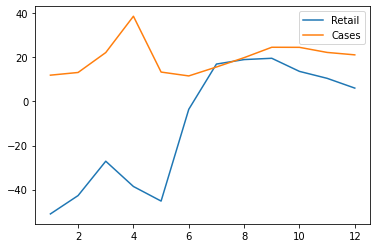

In [ ]:
plt.plot(df21.index, df21['Retail'])
plt.plot(df.index, df['Cases'])
plt.legend(['Retail','Cases'])

Bu grafikte perakende satış noktalırının ziyaret edilmesi ile vakalar arasındaki değişim görülmektedir.Türkiye'de tam kapanma süreci sonrası bu noktalara gidilme oranının artışı ile vaka sayılarının da hızla arttığı görülmektedir. Bu korelasyondan dolayı tahmin edeceğimiz lokasyonlardan ilkini seçtik.

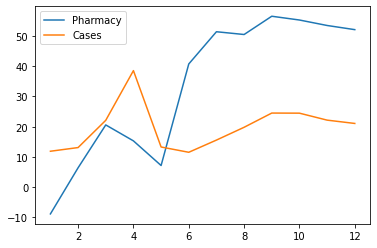

In [ ]:
plt.plot(df21.index, df21['Pharmacy'])
plt.plot(df.index, df['Cases'])
plt.legend(['Pharmacy','Cases'])

Bu grafikte eczanelerin ziyaret edilmesi ile vakalar arasındaki değişim görülmektedir.Türkiye'de tam kapanma süreci sonrası bu noktalara gidilme oranının artışı ile vaka sayılarının da hızla arttığı görülmektedir. Bu korelasyondan dolayı tahmin edeceğimiz lokasyonlardan ikincisi 'Pharmacy' oldu.

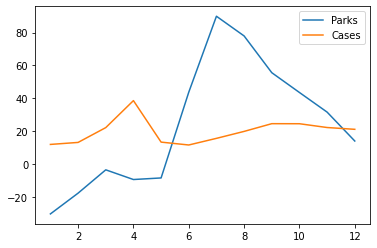

In [ ]:
plt.plot(df21.index, df21['Parks'])
plt.plot(df.index, df['Cases'])
plt.legend(['Parks','Cases'])

Bu grafikte parkların ziyaret edilmesi ile vakalar arasındaki değişim görülmektedir.Türkiye'de tam kapanma süreci sonrası bu noktalara gidilme oranınında diğer datalarımıza göre oldukça fazla bir artış gözlenmekte ve vaka sayılarının da hızla arttığı görülmektedir. Bu korelasyondan dolayı tahmin edeceğimiz lokasyonlardan üçüncü data grubumuzu seçtik.

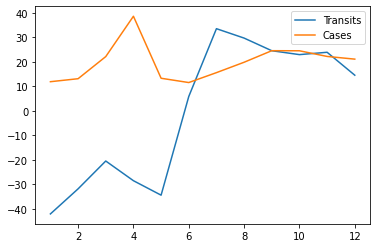

In [ ]:
plt.plot(df21.index, df21['Transits'])
plt.plot(df.index, df['Cases'])
plt.legend(['Transits','Cases'])

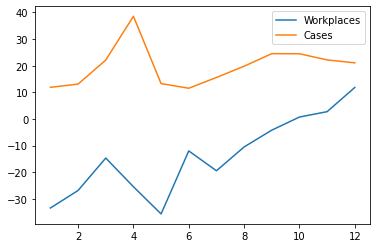

In [ ]:
plt.plot(df21.index, df21['Workplaces'])
plt.plot(df.index, df['Cases'])
plt.legend(['Workplaces','Cases'])

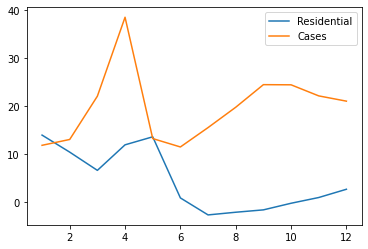

In [ ]:
plt.plot(df21.index, df21['Residential'])
plt.plot(df.index, df['Cases'])
plt.legend(['Residential','Cases'])

Bu grafikte evde kalma ile vakalar arasındaki değişim görülmektedir.Türkiye'de tam kapanma süreci sonrası evde kalma oranında farklı oranda değişimler gözlenmekte ve vaka sayılarının da hızla arttığı görülmektedir. Bu korelasyondan dolayı tahmin edeceğimiz lokasyonlardan sonuncusunu seçmiş olduk.

In [ ]:
df21 = pd.read_csv(url2021)
df = pd.read_csv(url1)

df = df.rename(columns={'Tarih':'date'})

df21 = df21.drop('metro_area',axis=1)
df21 = df21.drop('census_fips_code', axis=1)

df21 = df21.rename(columns={'retail_and_recreation_percent_change_from_baseline':'Retail'})
df21 = df21.rename(columns={'grocery_and_pharmacy_percent_change_from_baseline':'Pharmacy'})
df21 = df21.rename(columns={'parks_percent_change_from_baseline':'Parks'})
df21 = df21.rename(columns={'transit_stations_percent_change_from_baseline':'Transits'})
df21 = df21.rename(columns={'workplaces_percent_change_from_baseline':'Workplaces'})
df21 = df21.rename(columns={'residential_percent_change_from_baseline':'Residential'})

df21 = df21.iloc[:,6:13].dropna()
df21.index = pd.to_datetime(df21.date, format='%Y/%m/%d')
df21 = df21.groupby(by = [df21.index.month]).mean()
df21.info()

df['date'] = pd.to_datetime(df['date'])
df.index = pd.to_datetime(df.date, format='%d-%m-%Y')
df = df.groupby(by = [df.index.month]).mean()
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12 entries, 1 to 12
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Retail       12 non-null     float64
 1   Pharmacy     12 non-null     float64
 2   Parks        12 non-null     float64
 3   Transits     12 non-null     float64
 4   Workplaces   12 non-null     float64
 5   Residential  12 non-null     float64
dtypes: float64(6)
memory usage: 672.0 bytes
<class 'pandas.core.frame.DataFrame'>
Int64Index: 12 entries, 1 to 12
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Cases   12 non-null     float64
 1   PCR     12 non-null     float64
 2   Deaths  12 non-null     float64
 3   Healed  12 non-null     float64
dtypes: float64(4)
memory usage: 480.0 bytes


Datamızı en baştan bir hata olmaması adına tekrar okuduk.

15.679602408712261

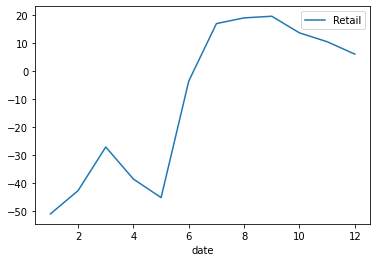

In [ ]:
dfR = df21.drop('Pharmacy',axis=1)
dfR = dfR.drop('Parks',axis=1)
dfR = dfR.drop('Transits',axis=1)
dfR = dfR.drop('Workplaces',axis=1)
dfR = dfR.drop('Residential',axis=1)
dfR.plot()
series_retail = dfR.values
retail = pd.DataFrame(series_retail)
retail = retail.rename(columns={0:'Retail'})
retail_df= pd.concat([retail,retail.shift(1)],axis=1)
retail_df.columns = ['Current', 'Forecast']
retail_test = retail_df[1:]
retail_error = mean_squared_error(retail_test.Current,retail_test.Forecast)
np.sqrt(retail_error)

Seçtiğimiz lokasyonlardan Perakende satış noktalarını yani 'Retail' verisini ayrı bir dataframeye çekerek burada önce basic bir model tanımladık. Bu model bizim bugünkü datamızı dünkü datamız olarak tahmin eden basit bir model  (projenin ilerleyen kısımlarında kullanılmayacak). Bu modelin hatasını ölçtük yazdırdık ardından da verimizi grafiğini çizdirerek kontrol ettik.

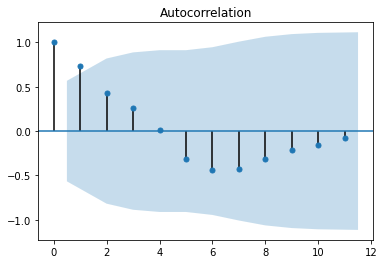

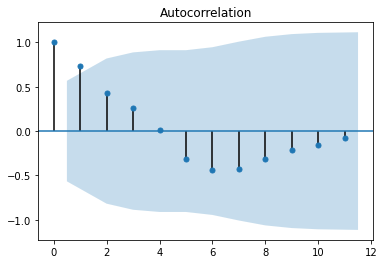

In [ ]:
plot_acf(dfR) # (p)

/usr/local/lib/python3.7/dist-packages/statsmodels/regression/linear_model.py:1358: RuntimeWarning: invalid value encountered in sqrt
  return rho, np.sqrt(sigmasq)


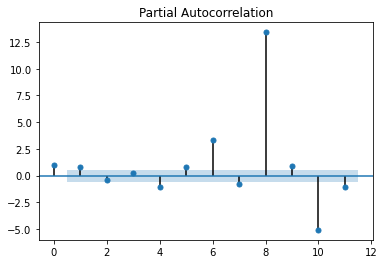

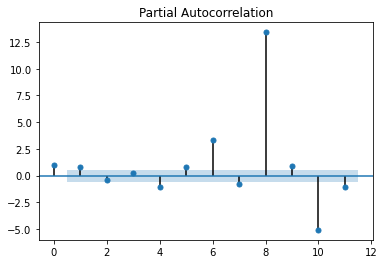

In [ ]:
plot_pacf(dfR) #(q)

Ardından ARIMA için kullanacağımız verinin p ve q değerleri diyebileceğimiz

otokorelasyon ve kısmi otokorelasyon grafiklerini çizdirerek inceledik.

In [ ]:
retail_train = dfR[0:9]
retail_tst = dfR[9:12]
retail_model = ARIMA(retail_train,order=(2,1,3))

/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/base/tsa_model.py:215: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/base/tsa_model.py:215: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)


Modelimiz için train, test verimizi ayarladık ve modelimizi tanımladık.

In [ ]:
retail_model_fit  = retail_model.fit()
retail_model_fit.aic

/usr/local/lib/python3.7/dist-packages/statsmodels/base/model.py:492: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  'available', HessianInversionWarning)


76.09223761357309

Gerekli katsayıyı burada kontrol ettik. Minimum olana kadar farklı p ve q değerleri ile tekrar çalıştırıldı.

In [ ]:
retail_forecast = retail_model_fit.forecast(steps=3)[0]
retail_forecast

array([18.41006409, 37.91851572, 39.94714779])

Forecasting işlemimizi yaptık ve aşagıda göründüğü gibi mean square erroru hesapladık.

In [ ]:
np.sqrt(mean_squared_error(retail_tst,retail_forecast))

25.364928311215845

Modelimizin mean square error fonksiyonu ile hata oranını ölçtük.



In [ ]:
retail_forecast = pd.DataFrame(retail_forecast)
retail_forecast = retail_forecast.rename(columns={0:'Retail'})
retail_forecast.index += 1
retail_forecast.info

<bound method DataFrame.info of       Retail
1  18.410064
2  37.918516
3  39.947148>

Text(0, 0.5, 'Retail')

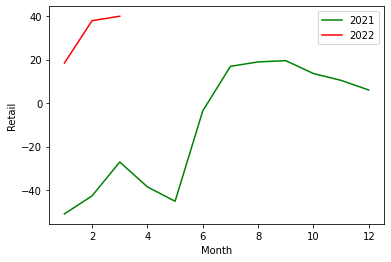

In [ ]:
plt.plot(df21.index,df21.Retail,color = 'green')
plt.plot(retail_forecast.index,retail_forecast.Retail, color= 'red')
plt.legend(['2021','2022'])
plt.xlabel('Month')
plt.ylabel('Retail')

2022 için tahmin ettiğimiz veri ile 2021 verisini görselleştirdik.

In [ ]:
retail_forecast.index = ['13','14','15']
retail_forecast.info
dfR = dfR.append(retail_forecast)
dfR.info

<bound method DataFrame.info of        Retail
1  -50.997523
2  -42.683964
3  -27.119765
4  -38.568564
5  -45.176812
6   -3.598578
7   16.901745
8   18.933854
9   19.521385
10  13.582923
11  10.438465
12   6.010673
13  18.410064
14  37.918516
15  39.947148>

Text(0, 0.5, '%')

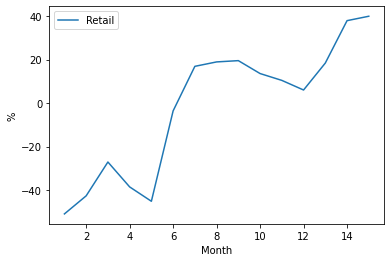

In [ ]:
plt.plot(dfR.index,dfR.Retail)
plt.legend(['Retail'])
plt.xlabel('Month')
plt.ylabel('%')

Ve 'Retail' için son olarak tahmin edilmiş veriyi ana veriye ekleyerek tekrar plot ettik. Görüldüğü üzere modelimizin tahmini insanların bu satış noktalarına daha fazla gideceği yönünde

12.85774299852379

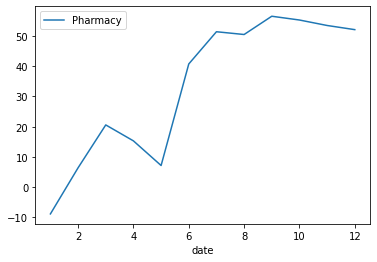

In [ ]:
dfPh = df21.drop('Retail',axis=1)
dfPh = dfPh.drop('Parks',axis=1)
dfPh = dfPh.drop('Transits',axis=1)
dfPh = dfPh.drop('Workplaces',axis=1)
dfPh = dfPh.drop('Residential',axis=1)
dfPh.plot()
series_pharmacy = dfPh.values
pharmacy = pd.DataFrame(series_pharmacy)
pharmacy = pharmacy.rename(columns={0:'Pharmacy'})
pharmacy_df= pd.concat([pharmacy,pharmacy.shift(1)],axis=1)
pharmacy_df.columns = ['Current', 'Forecast']
pharmacy_test = pharmacy_df[1:]
pharmacy_error = mean_squared_error(pharmacy_test.Current,pharmacy_test.Forecast)
np.sqrt(pharmacy_error)

Seçtiğimiz lokasyonlardan eczanelerin yani 'Pharmacy' verisini ayrı bir dataframeye çekerek burada önce basic bir model tanımladık. Bu model bizim bugünkü datamızı dünkü datamız olarak tahmin eden basit bir model  (projenin ilerleyen kısımlarında kullanılmayacak). Bu modelin hatasını ölçtük yazdırdık ardından da verimizi grafiğini çizdirerek kontrol ettik.

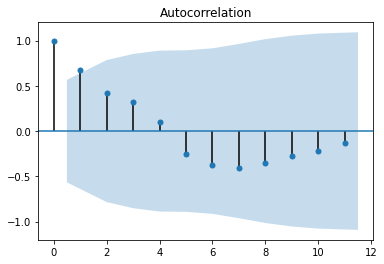

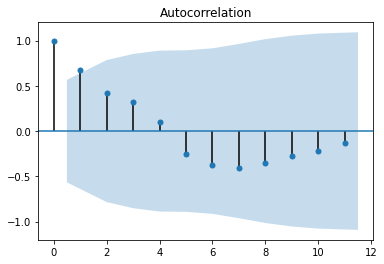

In [ ]:
plot_acf(dfPh) # (p)

/usr/local/lib/python3.7/dist-packages/statsmodels/regression/linear_model.py:1358: RuntimeWarning: invalid value encountered in sqrt
  return rho, np.sqrt(sigmasq)


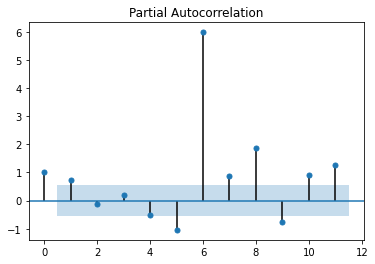

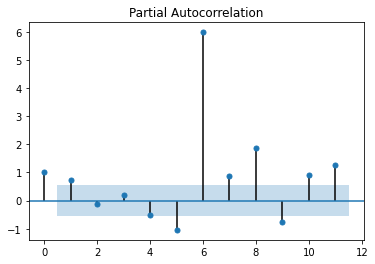

In [ ]:
plot_pacf(dfPh) #(q)

Ardından ARIMA için kullanacağımız verinin p ve q değerleri diyebileceğimiz otokorelasyon ve kısmi otokorelasyon grafiklerini çizdirerek inceledik.

In [ ]:
pharmacy_train = dfPh[0:9]
pharmacy_tst = dfPh[9:12]
pharmacy_model = ARIMA(pharmacy_train,order=(2,1,3))

/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/base/tsa_model.py:215: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/base/tsa_model.py:215: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)


Modelimiz için train, test verimizi ayarladık ve modelimizi tanımladık.

In [ ]:
pharmacy_model_fit  = pharmacy_model.fit()
pharmacy_model_fit.aic

/usr/local/lib/python3.7/dist-packages/statsmodels/base/model.py:492: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  'available', HessianInversionWarning)
/usr/local/lib/python3.7/dist-packages/statsmodels/base/model.py:512: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  "Check mle_retvals", ConvergenceWarning)


95.41448670552788

Gerekli katsayıyı burada kontrol ettik. Minimum olana kadar farklı p ve q değerleri ile tekrar çalıştırıldı.

In [ ]:
pharmacy_forecast = pharmacy_model_fit.forecast(steps=3)[0]
pharmacy_forecast

array([75.20706906, 75.12099734, 73.58815442])

In [ ]:
np.sqrt(mean_squared_error(pharmacy_tst,pharmacy_forecast))

20.98774102348024

In [ ]:
pharmacy_forecast = pd.DataFrame(pharmacy_forecast)
pharmacy_forecast = pharmacy_forecast.rename(columns={0:'Pharmacy'})
pharmacy_forecast.index += 1
pharmacy_forecast.info

<bound method DataFrame.info of     Pharmacy
1  75.207069
2  75.120997
3  73.588154>

Text(0, 0.5, 'Pharmacy')

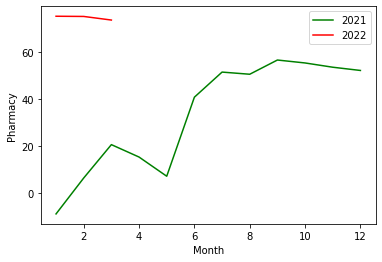

In [ ]:
plt.plot(df21.index,df21.Pharmacy,color = 'green')
plt.plot(pharmacy_forecast.index,pharmacy_forecast.Pharmacy, color= 'red')
plt.legend(['2021','2022'])
plt.xlabel('Month')
plt.ylabel('Pharmacy')

2022 için tahmin ettiğimiz veri ile 2021 verisini görselleştirdik.

In [ ]:
pharmacy_forecast.index = ['13','14','15']
pharmacy_forecast.info
dfPh = dfPh.append(pharmacy_forecast)
dfPh.info

<bound method DataFrame.info of      Pharmacy
1   -8.888695
2    6.391206
3   20.586774
4   15.302724
5    7.143771
6   40.773239
7   51.447908
8   50.531993
9   56.581128
10  55.332169
11  53.520403
12  52.143842
13  75.207069
14  75.120997
15  73.588154>

Text(0, 0.5, '%')

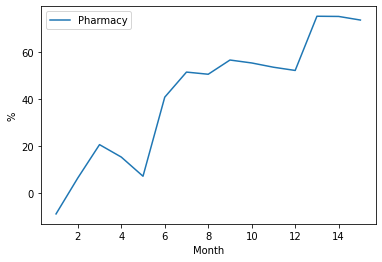

In [ ]:
plt.plot(dfPh.index,dfPh.Pharmacy)
plt.legend(['Pharmacy'])
plt.xlabel('Month')
plt.ylabel('%')

Ve 'Pharmacy' için son olarak tahmin edilmiş veriyi ana veriye ekleyerek tekrar plot ettik. Görüldüğü üzere modelimizin tahmini insanların eczanelere daha fazla gideceği yönünde

24.34137729598188

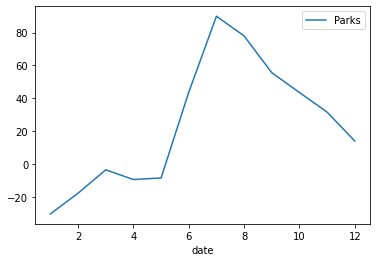

In [ ]:
dfP = df21.drop('Pharmacy',axis=1)
dfP = dfP.drop('Retail',axis=1)
dfP = dfP.drop('Transits',axis=1)
dfP = dfP.drop('Workplaces',axis=1)
dfP = dfP.drop('Residential',axis=1)
dfP.plot()
series_parks = dfP.values
parks = pd.DataFrame(series_parks)
parks = parks.rename(columns={0:'Parks'})
parks_df= pd.concat([parks,parks.shift(1)],axis=1)
parks_df.columns = ['Current', 'Forecast']
parks_test = parks_df[1:]
parks_error = mean_squared_error(parks_test.Current,parks_test.Forecast)
np.sqrt(parks_error)

Seçtiğimiz lokasyonlardan parkların yani 'Parks' verisini ayrı bir dataframeye çekerek burada önce basic bir model tanımladık. Bu model bizim bugünkü datamızı dünkü datamız olarak tahmin eden basit bir model (projenin ilerleyen kısımlarında kullanılmayacak). Bu modelin hatasını ölçtük yazdırdık ardından da verimizi grafiğini çizdirerek kontrol ettik.



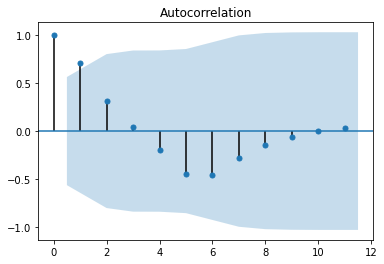

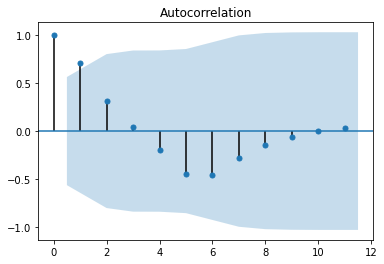

In [ ]:
plot_acf(dfP) # (p)

/usr/local/lib/python3.7/dist-packages/statsmodels/regression/linear_model.py:1358: RuntimeWarning: invalid value encountered in sqrt
  return rho, np.sqrt(sigmasq)


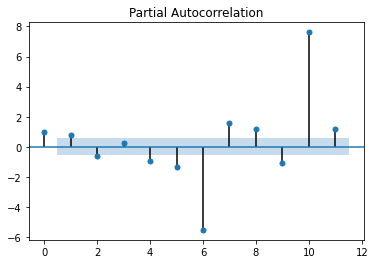

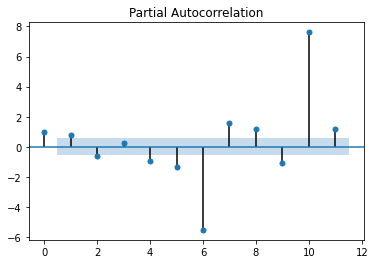

In [ ]:
plot_pacf(dfP) # (q)

Ardından ARIMA için kullanacağımız verinin p ve q değerleri diyebileceğimiz otokorelasyon ve kısmi otokorelasyon grafiklerini çizdirerek inceledik.

In [ ]:
parks_train = dfP[0:9]
parks_tst = dfP[9:12]
parks_model = ARIMA(parks_train,order=(2,1,3))

/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/base/tsa_model.py:215: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/base/tsa_model.py:215: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)


Modelimiz için train, test verimizi ayarladık ve modelimizi tanımladık.

In [ ]:
parks_model_fit  = parks_model.fit()
parks_model_fit.aic

/usr/local/lib/python3.7/dist-packages/statsmodels/base/model.py:492: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  'available', HessianInversionWarning)


75.53388871128828

Gerekli katsayıyı burada kontrol ettik. Minimum olana kadar farklı p ve q değerleri ile tekrar çalıştırıldı.

In [ ]:
parks_forecast = parks_model_fit.forecast(steps=3)[0]
parks_forecast

array([ 75.0355066 , 119.24268262, 137.69471331])

Forecasting işlemimizi yaptık ve aşagıda göründüğü gibi mean square erroru hesapladık.

In [ ]:
np.sqrt(mean_squared_error(parks_tst,parks_forecast))

89.43443736280491

In [ ]:
parks_forecast = pd.DataFrame(parks_forecast)
parks_forecast = parks_forecast.rename(columns={0:'Parks'})
parks_forecast.index += 1
parks_forecast.info

<bound method DataFrame.info of         Parks
1   75.035507
2  119.242683
3  137.694713>

Text(0, 0.5, 'Parks')

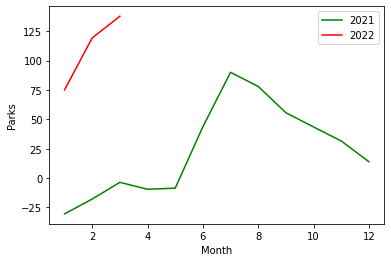

In [ ]:
plt.plot(df21.index,df21.Parks,color = 'green')
plt.plot(parks_forecast.index,parks_forecast.Parks, color= 'red')
plt.legend(['2021','2022'])
plt.xlabel('Month')
plt.ylabel('Parks')

2022 için tahmin ettiğimiz veri ile 2021 verisini görselleştirdik.

In [ ]:
parks_forecast.index = ['13','14','15']
parks_forecast.info
dfP = dfP.append(parks_forecast)
dfP.info

<bound method DataFrame.info of          Parks
1   -30.486742
2   -17.829292
3    -3.616458
4    -9.523875
5    -8.564370
6    43.706252
7    89.994410
8    77.982549
9    55.591446
10   43.521663
11   31.558934
12   13.944992
13   75.035507
14  119.242683
15  137.694713>

Text(0, 0.5, '%')

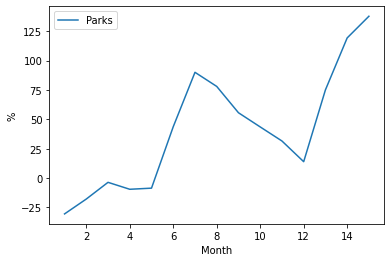

In [ ]:
plt.plot(dfP.index,dfP.Parks)
plt.legend(['Parks'])
plt.xlabel('Month')
plt.ylabel('%')

Ve 'Parks' için son olarak tahmin edilmiş veriyi ana veriye ekleyerek tekrar plot ettik. Görüldüğü üzere modelimizin tahmini insanların parklara daha fazla gideceği yönünde

4.670048221294358

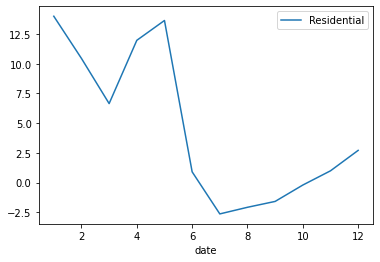

In [ ]:
dfRe = df21.drop('Retail',axis=1)
dfRe = dfRe.drop('Parks',axis=1)
dfRe = dfRe.drop('Transits',axis=1)
dfRe = dfRe.drop('Workplaces',axis=1)
dfRe = dfRe.drop('Pharmacy',axis=1)
dfRe.plot()
series_res = dfRe.values
res = pd.DataFrame(series_res)
res = res.rename(columns={0:'Residential'})
res_df= pd.concat([res,res.shift(1)],axis=1)
res_df.columns = ['Current', 'Forecast']
res_test = res_df[1:]
res_error = mean_squared_error(res_test.Current,res_test.Forecast)
np.sqrt(res_error)

Seçtiğimiz lokasyonlardan evde kalma yani 'Residential' verisini ayrı bir dataframeye çekerek burada önce basic bir model tanımladık. Bu model bizim bugünkü datamızı dünkü datamız olarak tahmin eden basit bir model (projenin ilerleyen kısımlarında kullanılmayacak). Bu modelin hatasını ölçtük yazdırdık ardından da verimizi grafiğini çizdirerek kontrol ettik.

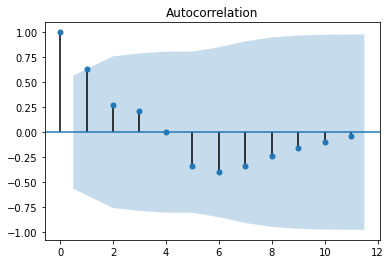

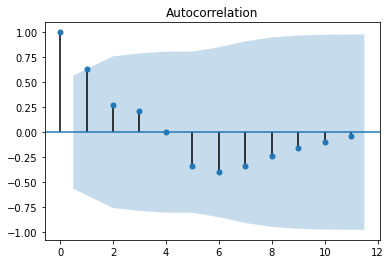

In [ ]:
plot_acf(dfRe) # (p)

/usr/local/lib/python3.7/dist-packages/statsmodels/regression/linear_model.py:1358: RuntimeWarning: invalid value encountered in sqrt
  return rho, np.sqrt(sigmasq)


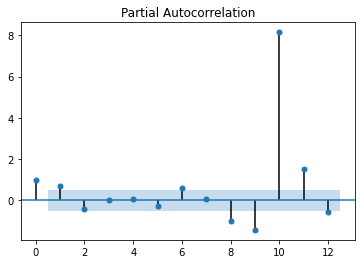

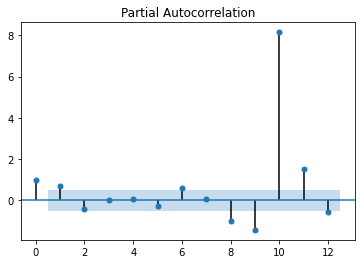

In [ ]:
plot_pacf(dfP) # (q)

Ardından ARIMA için kullanacağımız verinin p ve q değerleri diyebileceğimiz otokorelasyon ve kısmi otokorelasyon grafiklerini çizdirerek inceledik.

In [ ]:
res_train = dfRe[0:9]
res_tst = dfRe[9:12]
res_model = ARIMA(res_train,order=(2,1,3))

/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/base/tsa_model.py:215: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/base/tsa_model.py:215: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)


Modelimiz için train, test verimizi ayarladık ve modelimizi tanımladık.

In [ ]:
res_model_fit  = res_model.fit()
res_model_fit.aic

/usr/local/lib/python3.7/dist-packages/statsmodels/base/model.py:492: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  'available', HessianInversionWarning)


57.63177243760673

Gerekli katsayıyı burada kontrol ettik. Minimum olana kadar farklı p ve q değerleri ile tekrar çalıştırıldı.

In [ ]:
res_forecast = res_model_fit.forecast(steps=3)[0]
res_forecast

array([-7.62445495, -7.37852986, -7.54912237])

Forecasting işlemimizi yaptık ve aşagıda göründüğü gibi mean square erroru hesapladık.

In [ ]:
np.sqrt(mean_squared_error(res_tst,res_forecast))

8.75817526879477

In [ ]:
res_forecast = pd.DataFrame(res_forecast)
res_forecast = res_forecast.rename(columns={0:'Residential'})
res_forecast.index += 1
res_forecast.info

<bound method DataFrame.info of    Residential
1    -7.624455
2    -7.378530
3    -7.549122>

Text(0, 0.5, 'Residential')

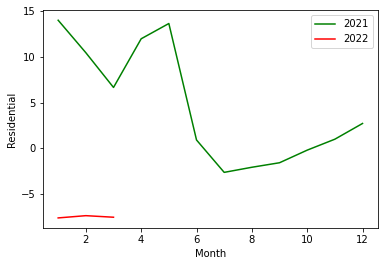

In [ ]:
plt.plot(df21.index,df21.Residential,color = 'green')
plt.plot(res_forecast.index,res_forecast.Residential, color= 'red')
plt.legend(['2021','2022'])
plt.xlabel('Month')
plt.ylabel('Residential')

2022 için tahmin ettiğimiz veri ile 2021 verisini görselleştirdik.

In [ ]:
res_forecast.index = ['13','14','15']
res_forecast.info
dfRe = dfRe.append(res_forecast)
dfRe.info

<bound method DataFrame.info of     Residential
1     13.998106
2     10.446654
3      6.646877
4     11.970309
5     13.641167
6      0.900595
7     -2.641877
8     -2.083763
9     -1.589782
10    -0.210919
11     0.986506
12     2.706732
13    -7.624455
14    -7.378530
15    -7.549122>

Text(0, 0.5, '%')

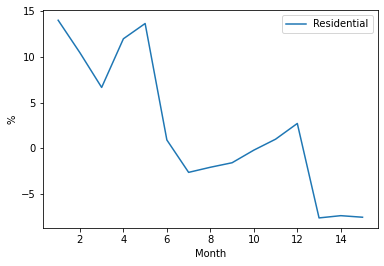

In [ ]:
plt.plot(dfRe.index,dfRe.Residential)
plt.legend(['Residential'])
plt.xlabel('Month')
plt.ylabel('%')

Ve 'Residential' için son olarak tahmin edilmiş veriyi ana veriye ekleyerek tekrar plot ettik. Görüldüğü üzere modelimizin tahmini insanların evlerinde daha az oturacağı yönünde. Bu çıkarımlar ışığında önümüzdeki üç ayda daha sosyal bir Türkiye görürken aynı zamanda temasın artmasından dolayı vaka sayılarında da artışların olacağı çıkarımını yapmak doğru olur.

Kaynakça:

 •	https://www.google.com/covid19/mobility/


 •	  https://covid19.saglik.gov.tr/TR-66935/genel-koronavirus-tablosu.html


  •	https://towardsdatascience.com/time-series-analysis-using-pandas-in-python-f726d87a97d8

•	https://towardsdatascience.com/time-series-modeling-using-scikit-pandas-and-numpy-682e3b8db8d1

•	https://scikit-learn.org/stable/modules/cross_validation.html#time-series-split

•	https://scikit-learn.org/stable/auto_examples/applications/plot_cyclical_feature_engineering.html#sphx-glr-auto-examples-applications-plot-cyclical-feature-engineering-py


